# Feature Engineering

## Objetivo

Preparar las variables para el entrenamiento de modelos de Machine Learning mediante técnicas de preprocesamiento, selección de variables y transformaciones necesarias.

## Alcance de esta fase

- Evaluar la necesidad de escalado de las variables.
- Analizar la relevancia de las características disponibles.
- Aplicar las transformaciones necesarias para el modelado.
- Generar un conjunto de datos preparado para el entrenamiento de modelos.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/creditcard.csv")
df = df.drop_duplicates()

In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [4]:
df[["Time", "Amount"]].describe()

,Time,Amount
count,283726.000000,283726.000000
mean,94811.077600,88.472687
std,47481.047891,250.399437
min,0.000000,0.000000
25%,54204.750000,5.600000
50%,84692.500000,22.000000
75%,139298.000000,77.510000
max,172792.000000,25691.160000


array([[<Axes: title={'center': 'Time'}>,
        <Axes: title={'center': 'Amount'}>]], dtype=object)

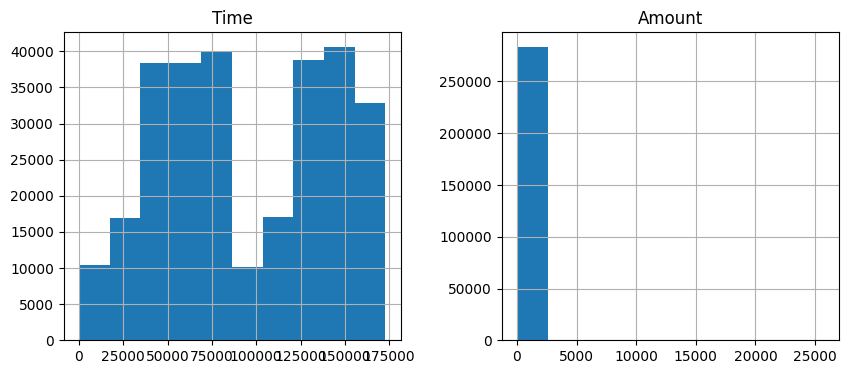

In [5]:
df[["Time", "Amount"]].hist(figsize=(10,4))

In [8]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

In [9]:
df[["Time", "Amount"]].skew()

Time      -0.035581
Amount    16.978803
dtype: float64

In [10]:
from sklearn.preprocessing import RobustScaler

In [11]:
scaler = RobustScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [12]:
df[["Amount", "Amount_scaled"]].describe()

,Amount,Amount_scaled
count,283726.000000,283726.000000
mean,88.472687,0.924387
std,250.399437,3.482123
min,0.000000,-0.305938
25%,5.600000,-0.228063
50%,22.000000,0.000000
75%,77.510000,0.771937
max,25691.160000,356.962314


<Axes: >

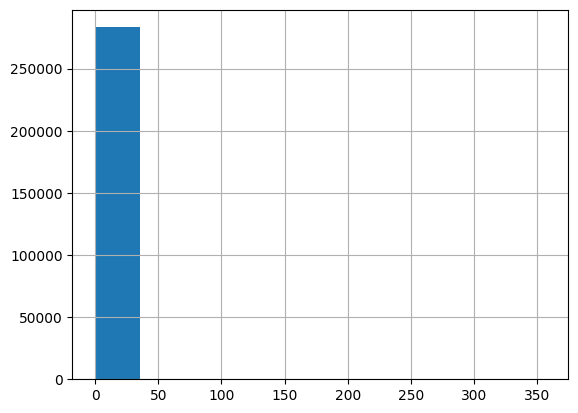

In [13]:
df["Amount_scaled"].hist()

In [14]:
df[["V17", "V14", "V12", "V10", "V16", "V3", "V7"]].describe()

,V17,V14,V12,V10,V16,V3,V7
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,0.000170,0.000252,-0.000715,-0.001441,0.001162,0.001613,0.001801
std,0.842507,0.952215,0.994674,1.076407,0.873696,1.508682,1.227664
min,-25.162799,-19.214325,-18.683715,-24.588262,-14.129855,-48.325589,-43.557242
25%,-0.483928,-0.425732,-0.406198,-0.535578,-0.466860,-0.889682,-0.552509
50%,-0.065867,0.050209,0.139072,-0.093237,0.067119,0.179963,0.040859
75%,0.398972,0.492336,0.616976,0.453619,0.523512,1.026960,0.570474
max,9.253526,10.526766,7.848392,23.745136,17.315112,9.382558,120.589494


In [15]:
df[["Time", "Amount", "Class"]].corr()

,Time,Amount,Class
Time,1.000000,-0.010559,-0.012359
Amount,-0.010559,1.000000,0.005777
Class,-0.012359,0.005777,1.000000


In [16]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Amount_scaled'],
      dtype='str')

In [17]:
df = df.drop(columns=["Amount"])

In [18]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class',
       'Amount_scaled'],
      dtype='str')

# Conclusiones de Feature Engineering

## Principales hallazgos

* La variable **Amount** presenta una fuerte asimetría positiva y una cantidad significativa de valores extremos (outliers).

* El análisis de asimetría mostró que **Amount** presenta un valor de skew cercano a **17**, mientras que **Time** presenta una distribución mucho más equilibrada.

* Las variables **V1-V28**, generadas mediante PCA, ya se encuentran aproximadamente centradas y en escalas similares.

* El análisis realizado indica que no es necesario aplicar escalado adicional a las variables derivadas de PCA.

## Transformaciones realizadas

* Se aplicó **RobustScaler** sobre la variable **Amount** debido a la presencia de asimetría y valores extremos.

* Como resultado, se generó la nueva variable **Amount_scaled**.

* La variable original **Amount** fue sustituida por **Amount_scaled** para su utilización en las fases posteriores del proyecto.

## Selección de variables

* No se eliminaron variables durante esta fase.

* Se decidió conservar todas las variables predictoras para el entrenamiento inicial de los modelos.

* Aunque **Time** y **Amount** mostraron una relación débil con la variable objetivo durante el EDA, se optó por mantenerlas debido al reducido número de variables disponibles y a su posible contribución al rendimiento de los modelos.

## Resultado final

* El dataset quedó compuesto por **30 variables predictoras** y **1 variable objetivo (Class)**.

* Se completó el proceso de preparación de variables necesario para el entrenamiento y evaluación de modelos de Machine Learning.
